Project Initial Approach

I began this project with a broad question: how accurately can UK constituency-level general election results be predicted without identifying the constituencies themselves?

My initial motivation for excluding constituency names and identifiers was to avoid building a model that simply learns the historical behaviour of individual seats. While constituency identity would likely contain considerable predictive information, parliamentary boundary reviews periodically alter or replace constituencies. I therefore wanted to investigate whether a model could instead rely on characteristics that remain meaningful when moving from one election to another.

To investigate this, I first looked for historical data that could provide a sufficiently large set of elections on which to train a model. I found a House of Commons Library dataset containing constituency-level general election results from 1918 to 2019, alongside Mark Pack's dataset containing month average polling data. Together, these provided a starting point for constructing observations that combined the circumstances of each constituency with the national political environment at each election.

One immediate problem was deciding how much information about a constituency the model should be allowed to know. Removing constituency identity was intentional, but removing its previous election result as well seemed likely to artificially weaken the model. A constituency previously won comfortably by Labour clearly contains different predictive information from one previously won comfortably by the Conservatives. Without some representation of this electoral history, relatively little information would remain to distinguish constituencies experiencing the same national political conditions.

I therefore decided to include the previous winning party and previous majority proportion as predictors. This preserved information about a constituency's recent electoral behaviour without explicitly telling the model which constituency it was.

This decision introduced another problem. Constituencies do not always retain the same boundaries between elections. Simply joining a constituency to its previous result would therefore produce incorrect or missing comparisons whenever a boundary review had taken place.

This led me to investigate notional election results. Rallings and Thrasher have reconstructed previous general election results on newly introduced constituency boundaries, estimating what the previous election result would have been had those boundaries already existed. Where these estimates were available, I could therefore use them to construct a more meaningful previous result for constituencies affected by boundary changes.

At this stage, my aim was to construct a dataset in which each row represented a constituency at a particular general election, described using information that would have been available before that election. 

Constructing the Modelling Dataset

The data required for this analysis came from several sources and were not initially in a form that could be compared directly. I therefore first cleaned the individual source datasets independently using Python and pandas. This included standardising variables and producing consistent representations of the information required for later analysis.

I then loaded the cleaned datasets into a DuckDB database. SQL was used to combine elections with their corresponding previous results, substitute notional previous results where appropriate, and join constituency-level observations to the national polling information for each election.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.read_csv('../Data/test train/TRAIN.csv')
test_data = pd.read_csv('../Data/test train/TEST.csv')

train_data.columns


Index(['constituency_name', 'country/region', 'election',
       'majority_proportion', 'winner', 'constituency_id', 'boundary_set',
       'election_type', 'previous_election', 'previous_majority_proportion',
       'previous_winner', 'Conservative', 'Labour', 'LD', 'incumbent',
       'supported_incumbent', 'incumbent_polling', 'opposition_polling'],
      dtype='str')

In [3]:
need_cols = ['country/region','previous_majority_proportion',
       'previous_winner','Conservative', 'Labour', 'incumbent','winner']

num_columns = ['previous_majority_proportion', 'Conservative', 'Labour']
cat_columns = ['country/region', 'previous_winner', 'incumbent']

train_data = train_data[need_cols]
test_data = test_data[need_cols]

In [4]:
train_data.isna().sum()

country/region                  0
previous_majority_proportion    0
previous_winner                 0
Conservative                    0
Labour                          0
incumbent                       0
winner                          0
dtype: int64

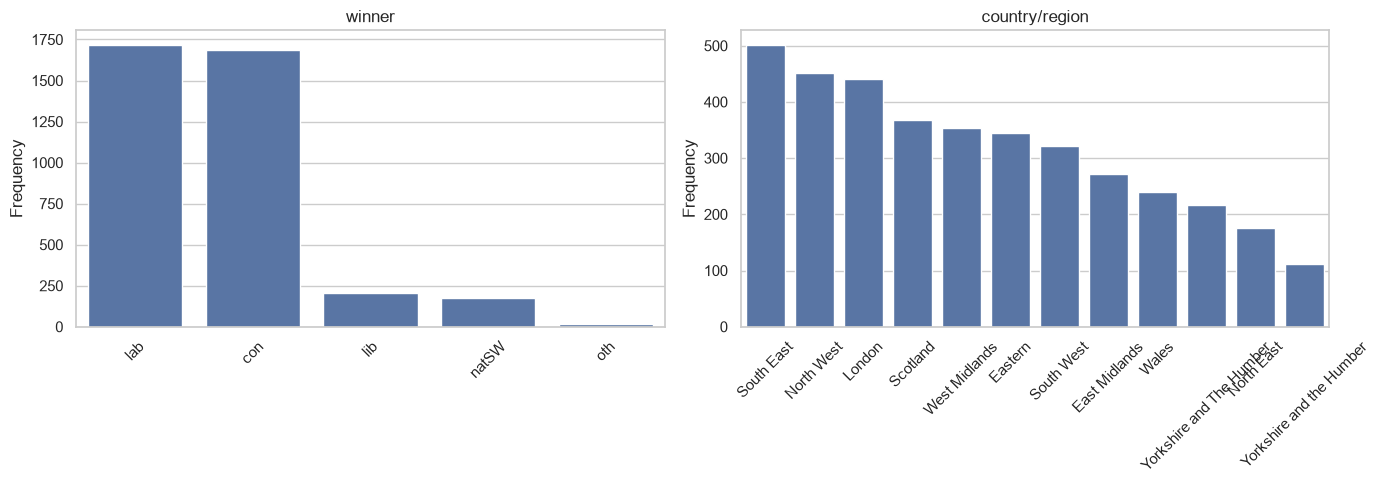

In [15]:
frequency_columns = ['winner', 'country/region']

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, column in zip(axes, frequency_columns):
    order = train_data[column].value_counts().index
    sns.countplot(
        data=train_data,
        x=column,
        order=order,
        ax=ax
    )
    ax.set_title(column)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [16]:
print("there are " + str((train_data['winner'] == 'oth').sum()) + ' other party constituencies')

there are 16 other party constituencies


Since there are only 16 constituencies over the elections which voted for parties other than the Conservative, Labour, Lib Dem, SNP or PLaid Cymru, it is likely worth removing these constituencies. It is important to note how this will limit the model for recognising new political parties, however it is likely this will need to be tackled more explicitly anyway.

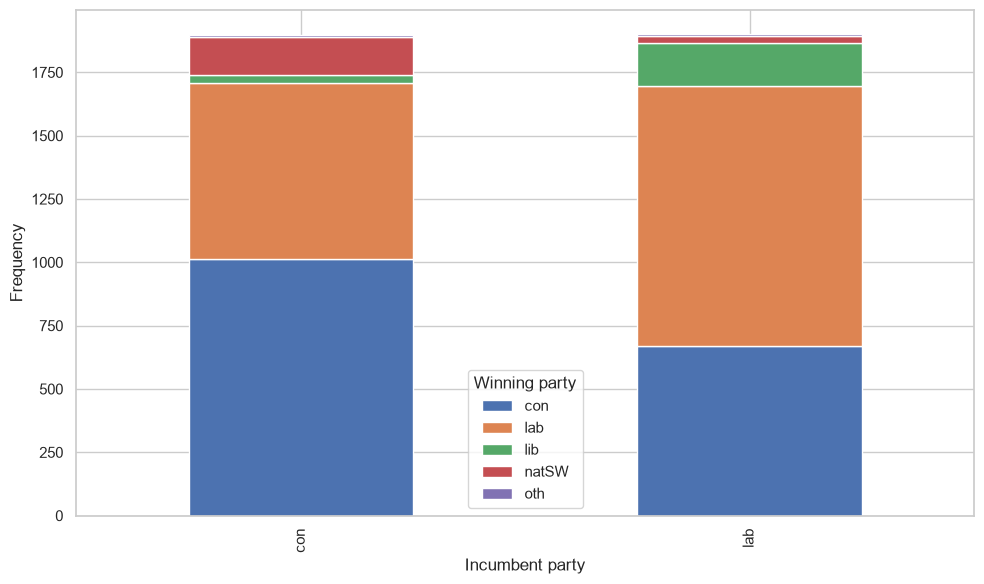

In [6]:

party_counts = pd.crosstab(train_data['incumbent'], train_data['winner'])

sns.set_theme(style='whitegrid')
party_counts.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.xlabel('Incumbent party')
plt.ylabel('Frequency')
plt.legend(title='Winning party')
plt.tight_layout()
plt.show()


This bar chart reflects my intial suspicion that we may be over-representing elections where the incumbent party gets re-elected. I wasn't able to find notional results for the 1992 election, so so far the only election contained in the data set where the opposition party was elected is the 2010 election. This could provide a  problem scaling for future election, especially 2024 — where labour won in opposition (unprecedented in the dataset).

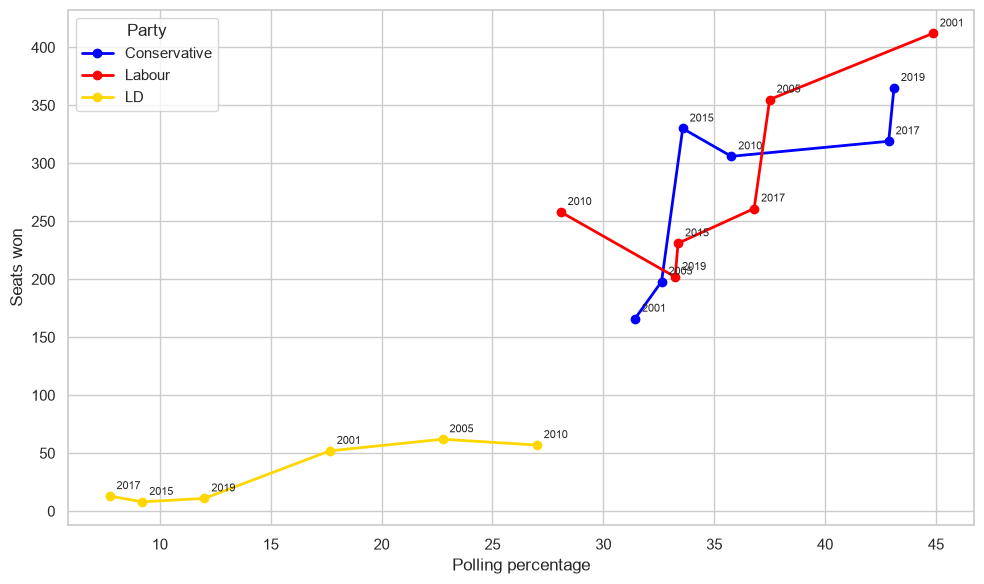

In [10]:
plot_data = pd.read_csv('../Data/test train/TRAIN.csv')

parties = ['Conservative', 'Labour', 'LD']
party_colours = {
    'Conservative': 'blue',
    'Labour': 'red',
    'LD': 'gold'
}
winner_map = {
    'con': 'Conservative',
    'lab': 'Labour',
    'lib': 'LD'
}

plot_data['winner_party'] = plot_data['winner'].map(winner_map)

polling_by_election = plot_data.groupby('election')[parties].first().reset_index()

seats_by_election = (
    plot_data.dropna(subset=['winner_party'])
    .groupby(['election', 'winner_party'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=parties, fill_value=0)
    .reset_index()
)

polling_long = polling_by_election.melt(
    id_vars='election',
    value_vars=parties,
    var_name='party',
    value_name='polling'
)

seats_long = seats_by_election.melt(
    id_vars='election',
    value_vars=parties,
    var_name='party',
    value_name='seats'
)

party_performance = polling_long.merge(seats_long, on=['election', 'party'])

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

for party in parties:
    party_data = party_performance[party_performance['party'] == party].sort_values('polling')
    plt.plot(
        party_data['polling'],
        party_data['seats'],
        marker='o',
        linewidth=2,
        color=party_colours[party],
        label=party
    )

    for _, row in party_data.iterrows():
        plt.annotate(
            int(row['election']),
            (row['polling'], row['seats']),
            textcoords='offset points',
            xytext=(5, 5),
            fontsize=8
        )

plt.xlabel('Polling percentage')
plt.ylabel('Seats won')
plt.legend(title='Party')
plt.tight_layout()
plt.show()


Not much to infer from this.

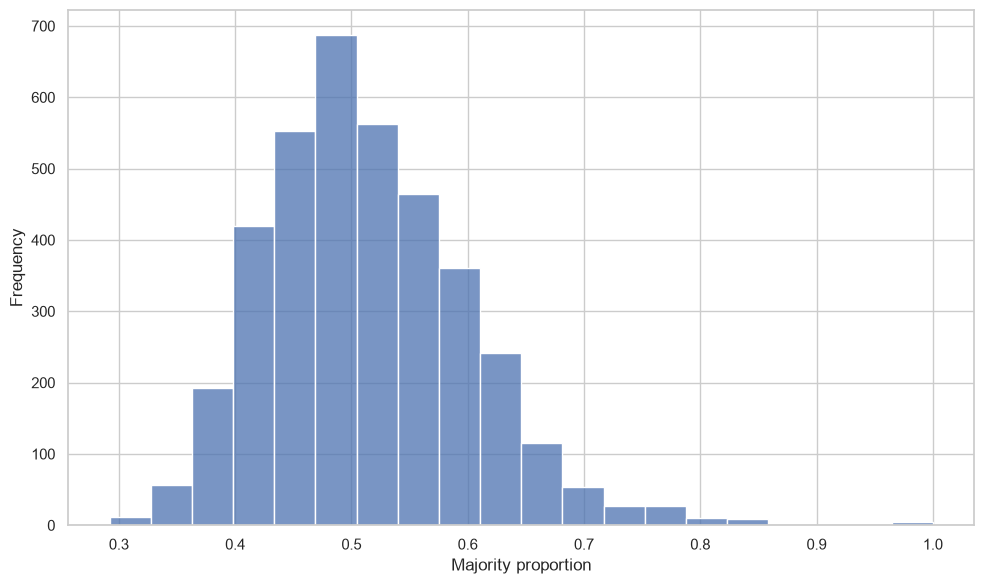

In [11]:
plot_data = pd.read_csv('../Data/test train/TRAIN.csv')

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x='majority_proportion',
    bins=20
)

plt.xlabel('Majority proportion')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Approximately normally distributed so no transformation will be needed for models that require it. Although does have a small skew.  